<a href="https://colab.research.google.com/github/rakshitha-dev9/AIML/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [7]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                prediction = np.dot(self.w, X[i]) + self.b

                if y[i] * prediction <= 0:
                    self.w = self.w + self.lr * y[i] * X[i]
                    self.b = self.b + self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [8]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output
            z = np.dot(X, self.w) + self.b

            # 2. Calculate gradients
            dw = (1 / n) * X.T.dot(z - y)
            db = (1 / n) * np.sum(z - y)

            # 3. Update w and b
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            # Track cost (MSE) for the convergence plot later
            cost = (1 / n) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [9]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Margin condition check: y_i * (w . x_i + b) >= 1
                condition = y[i] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_margin = MarginWaterClassifier()
model_margin.fit(X_train, y_train)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

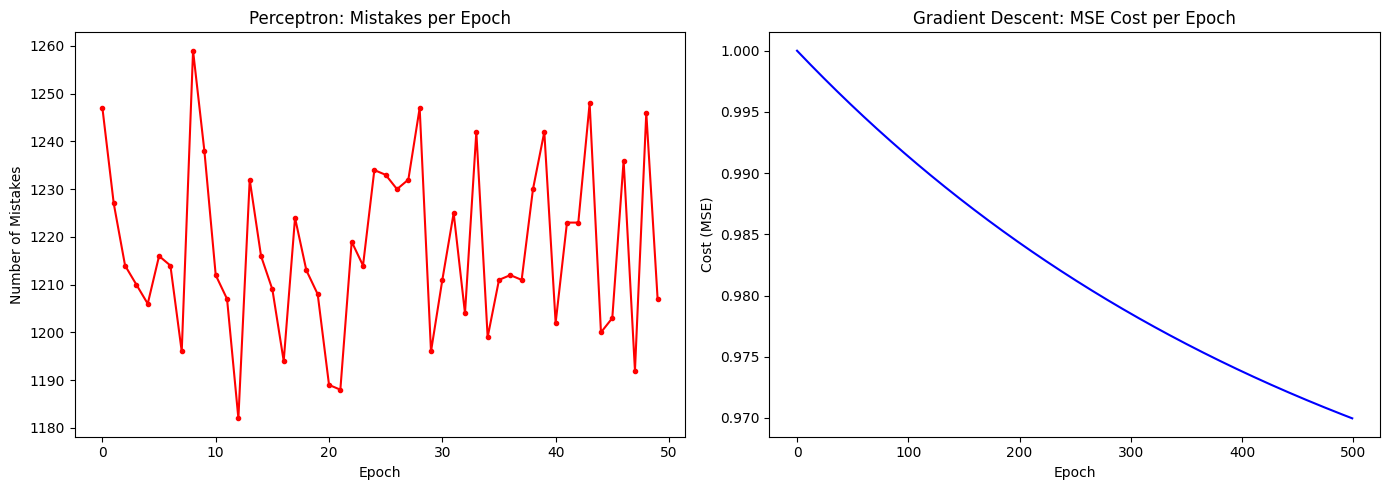

Test Accuracy Comparison
------------------------
Perceptron:        0.5015
Gradient Descent:  0.6280
Margin Classifier: 0.6280


In [10]:
from sklearn.metrics import accuracy_score

# --- Task 1: Convergence Plot ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(len(model_p.mistakes)), model_p.mistakes, 'r.-')
ax[0].set_title('Perceptron: Mistakes per Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Number of Mistakes')

ax[1].plot(range(len(model_gd.cost_history)), model_gd.cost_history, 'b-')
ax[1].set_title('Gradient Descent: MSE Cost per Epoch')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Cost (MSE)')

plt.tight_layout()
plt.show()

# --- Task 2: Accuracy Report ---
pred_p = model_p.predict(X_test)
pred_gd = model_gd.predict(X_test)
pred_margin = model_margin.predict(X_test)

acc_p = accuracy_score(y_test, pred_p)
acc_gd = accuracy_score(y_test, pred_gd)
acc_margin = accuracy_score(y_test, pred_margin)

print("Test Accuracy Comparison")
print("------------------------")
print(f"Perceptron:        {acc_p:.4f}")
print(f"Gradient Descent:  {acc_gd:.4f}")
print(f"Margin Classifier: {acc_margin:.4f}")

### Safety Margin Analysis

If a water sample is right near the decision boundary, I'd trust the Margin Classifier more than the Perceptron. Perceptron only cares if you're on the correct side of the line, even if it's by a tiny amount — it stops updating as soon as it's "technically" correct, so borderline points don't really get treated with any extra caution. The Margin Classifier actually penalizes points that are too close to the boundary (not just wrong ones), so it tries to keep some breathing room around the decision line. For something like water safety, that extra buffer matters — you don't want a borderline sample getting labeled "safe" just because it barely crossed the line.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


**1:** If the learning rate is too high, like 1.0, the model basically takes steps that are way too big. Instead of slowly walking down towards the minimum of the loss function, it overshoots past it every time, and can end up further away than it started. Over epochs this usually means the cost doesn't go down smoothly, it either bounces around a lot or just blows up completely. Actually we saw this exact thing happen in the Gradient Descent lab — when we tried lr=1.5 for Batch GD the error shot up to some insane number instead of dropping. Same idea here.

**2:** We use {-1, 1} instead of {0, 1} because it makes the math for checking mistakes way cleaner. If y is -1 or 1, then y * prediction is positive when we got it right and negative when we got it wrong, so we can just check "is y*prediction <= 0" to catch mistakes in one line. If we used 0 and 1 instead, this breaks because multiplying by 0 just kills that term completely, so the whole "mistake check" logic wouldn't make sense anymore. That's why perceptron and hinge loss specifically need the ±1 labels to work properly.

**3:** Out of the three, the Margin Classifier handles this messy data best. The Perceptron basically assumes there's a perfect line that separates the classes, and if that's not true (which it isn't here, since the water data isn't cleanly separable) it just keeps changing forever and never really settles — which is probably why it landed at like 50% accuracy, basically a coin flip. The margin classifier is more forgiving since hinge loss lets some points be wrong or close to the boundary without freaking out, and the L2 regularization keeps the weights from getting too extreme because of outliers. That's probably why both GD and the margin model did noticeably better (62.8%) than plain perceptron.